In [1]:
### ===== Cell 1 ===== ###

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import statsmodels.api as sm
import xgboost as xgb
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score

# Set working directory to project root
os.chdir("C:/Technion/Semester9/Deep Learning Code/Project")

# Import your custom modules
from src.models.att_clx_hybrid import AttCLXHybrid
from src.models.att_clx_utils import NormalizeMult, create_dataset, evaluation_metric

print("✅ Environment ready.")

### ===== End of Cell 1 ===== ###

✅ Environment ready.


In [2]:
### ===== Cell 2 ===== ###

# Load raw data
df = pd.read_csv('Data/601988.SH.csv')
df['trade_date'] = pd.to_datetime(df['trade_date'], format='%Y%m%d')
df = df.sort_values('trade_date').set_index('trade_date')

print("Generating ARIMA(2,1,0) residuals...")
# Reference logic: Use the 'close' price to find the linear trend
model_arima = sm.tsa.ARIMA(df['close'], order=(2, 1, 0))
model_fit = model_arima.fit()

# Create the residuals file required by the NN model
residuals = pd.DataFrame(model_fit.resid, columns=['residuals'])
residuals.to_csv('Data/ARIMA_residuals1.csv')

# Create the linear predictions file for the hybrid sum logic
predictions_arima = model_fit.predict()
predictions_arima.to_csv('Data/ARIMA.csv')

print("✅ Pre-processing complete. 'ARIMA_residuals1.csv' generated.")

### ===== End of Cell 2 ===== ###

Generating ARIMA(2,1,0) residuals...


C:\Users\omrym\anaconda3\envs\deep_learn\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\omrym\anaconda3\envs\deep_learn\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\omrym\anaconda3\envs\deep_learn\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


✅ Pre-processing complete. 'ARIMA_residuals1.csv' generated.


In [3]:
### ===== Cell 3 ===== ###

# 1. Load both files
raw_df = pd.read_csv('Data/601988.SH.csv')
res_df = pd.read_csv('Data/ARIMA_residuals1.csv')

# 2. Match dates
raw_df['trade_date'] = pd.to_datetime(raw_df['trade_date'], format='%Y%m%d')
res_df['trade_date'] = pd.to_datetime(res_df['trade_date'])
merged_df = pd.merge(raw_df, res_df, on='trade_date')

# 3. Reference Feature List: [open, high, low, close, vol, amount, residuals]
features = merged_df[['open', 'high', 'low', 'close', 'vol', 'amount', 'residuals']].values.astype('float64')

print(f"Merged Data Shape: {features.shape}")


### ===== End of Cell 3 ===== ###

Merged Data Shape: (3681, 7)


In [4]:
### ===== Cell 4 ===== ###

# 1. Percentile Normalization (0-100)
data_norm, norm_params = NormalizeMult(features)

# 2. Create 20-day Sliding Windows
# X: (N, 20, 7), Y_raw: (N, 7)
X, Y_raw = create_dataset(data_norm, look_back=20)

# 3. Classification Labeling
# We determine if the 'close' (index 3) goes Up, Down, or Neutral
labels = []
for i in range(len(Y_raw)):
    prev_close = X[i, -1, 3]
    next_close = Y_raw[i, 3]
    diff = (next_close - prev_close) / (prev_close + 1e-9)

    if diff < -0.002: labels.append(0)   # Down
    elif diff > 0.002: labels.append(2)  # Up
    else: labels.append(1)               # Neutral (Stable)

X_tensor = torch.FloatTensor(X)
Y_tensor = torch.LongTensor(labels)

# 4. Reference Split (Index 3500)
train_X, train_Y = X_tensor[:3500], Y_tensor[:3500]
val_X, val_Y = X_tensor[3500:], Y_tensor[3500:]

train_loader = DataLoader(TensorDataset(train_X, train_Y), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(val_X, val_Y), batch_size=32, shuffle=False)

print(f"Training Samples: {len(train_X)}, Validation Samples: {len(val_X)}")


### ===== End of Cell 4 ===== ###

Training Samples: 3500, Validation Samples: 160


In [5]:
### ===== Cell 5 ===== ###

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AttCLXHybrid(input_dim=7, time_steps=20, lstm_units=64, output_dim=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("Starting Neural Network Training...")
for epoch in range(50):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/50], Avg Loss: {epoch_loss/len(train_loader):.4f}")

torch.save(model.state_dict(), "src/models/att_clx_stock.pth")


### ===== End of Cell 5 ===== ###

Starting Neural Network Training...
Epoch [10/50], Avg Loss: 0.9876
Epoch [20/50], Avg Loss: 0.9856
Epoch [30/50], Avg Loss: 0.9838
Epoch [40/50], Avg Loss: 0.9778
Epoch [50/50], Avg Loss: 0.9713


In [6]:
### ===== Cell 6 ===== ###

# 1. Get NN predictions for the validation set
model.eval()
with torch.no_grad():
    nn_output = model(val_X.to(device))
    nn_probs = torch.softmax(nn_output, dim=1).cpu().numpy()

# 2. Combine NN probabilities with raw market features for XGBoost
# We use the probabilities + the last day's features from the window
xgb_features = np.hstack([nn_probs, val_X[:, -1, :].numpy()])
xgb_labels = val_Y.numpy()

# 3. Train XGBoost on the first half of validation to predict the second
# (Reference walk-forward validation logic)
split = len(xgb_features) // 2
train_features, test_features = xgb_features[:split], xgb_features[split:]
train_labels, test_labels = xgb_labels[:split], xgb_labels[split:]

xgb_meta = xgb.XGBClassifier(n_estimators=50, max_depth=6, objective='multi:softprob')
xgb_meta.fit(train_features, train_labels)

# 4. Final Comparison
final_preds = xgb_meta.predict(test_features)
nn_only_preds = np.argmax(nn_probs[split:], axis=1)

print("\n" + "="*30)
print("HYBRID MODEL RESULTS")
print("="*30)
print(f"Neural Network Accuracy: {accuracy_score(test_labels, nn_only_preds):.4f}")
print(f"Hybrid (NN + XGBoost) Accuracy: {accuracy_score(test_labels, final_preds):.4f}")


### ===== End of Cell 6 ===== ###


HYBRID MODEL RESULTS
Neural Network Accuracy: 0.3625
Hybrid (NN + XGBoost) Accuracy: 0.3375


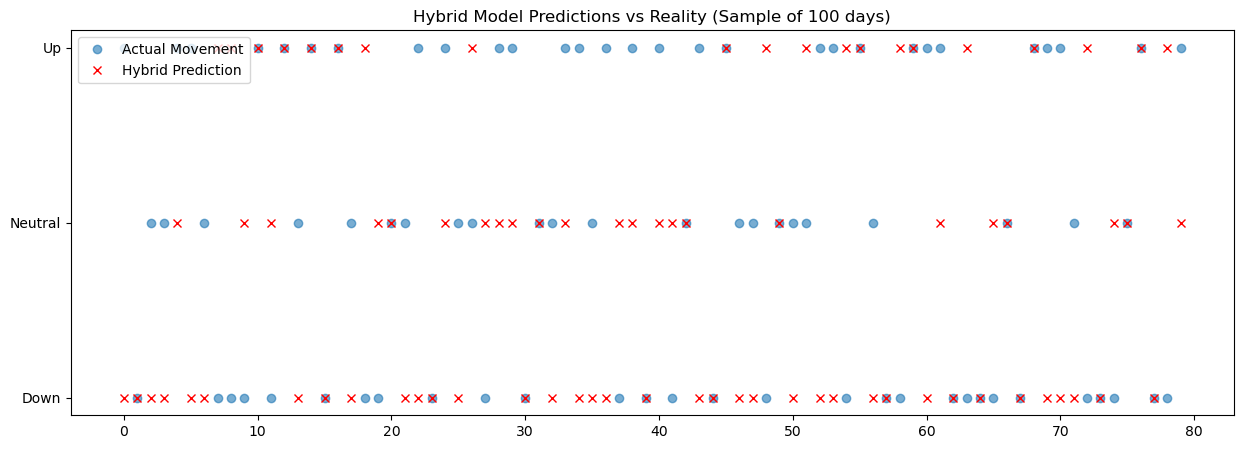

In [7]:
import matplotlib.pyplot as plt

# Plotting a segment of the validation results
plt.figure(figsize=(15, 5))
plt.plot(test_labels[:100], label='Actual Movement', marker='o', linestyle='', alpha=0.6)
plt.plot(final_preds[:100], label='Hybrid Prediction', marker='x', linestyle='', color='red')
plt.title('Hybrid Model Predictions vs Reality (Sample of 100 days)')
plt.yticks([0, 1, 2], ['Down', 'Neutral', 'Up'])
plt.legend()
plt.show()

ANALYZING NEURAL NETWORK ONLY:


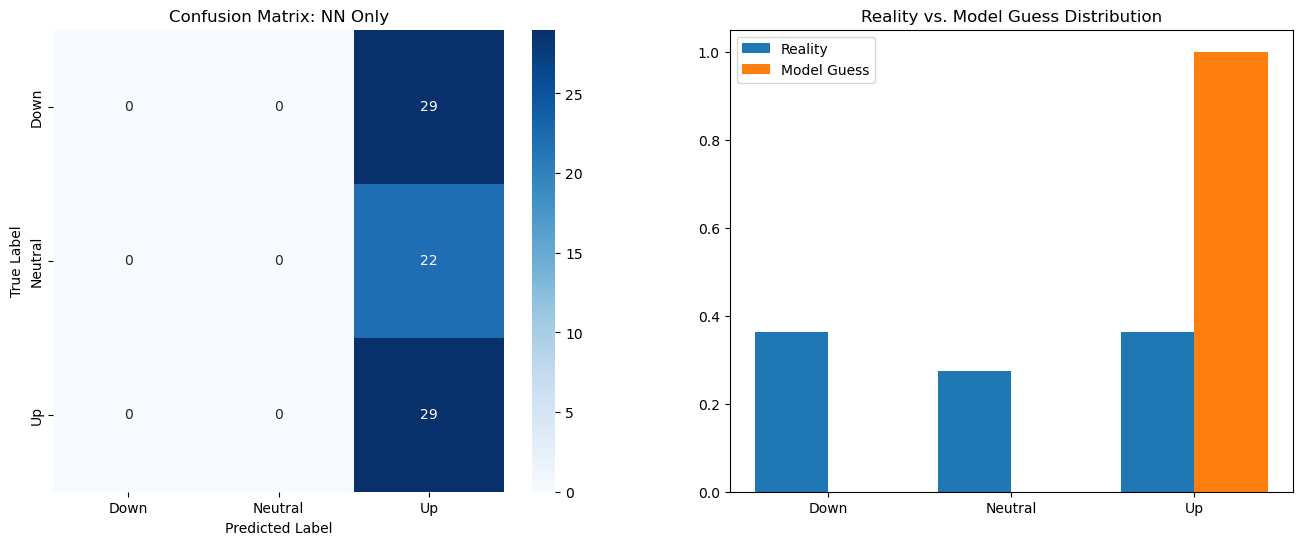

C:\Users\omrym\anaconda3\envs\deep_learn\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\omrym\anaconda3\envs\deep_learn\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\omrym\anaconda3\envs\deep_learn\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

              precision    recall  f1-score   support

        Down       0.00      0.00      0.00        29
     Neutral       0.00      0.00      0.00        22
          Up       0.36      1.00      0.53        29

    accuracy                           0.36        80
   macro avg       0.12      0.33      0.18        80
weighted avg       0.13      0.36      0.19        80


ANALYZING HYBRID (NN + XGBOOST):


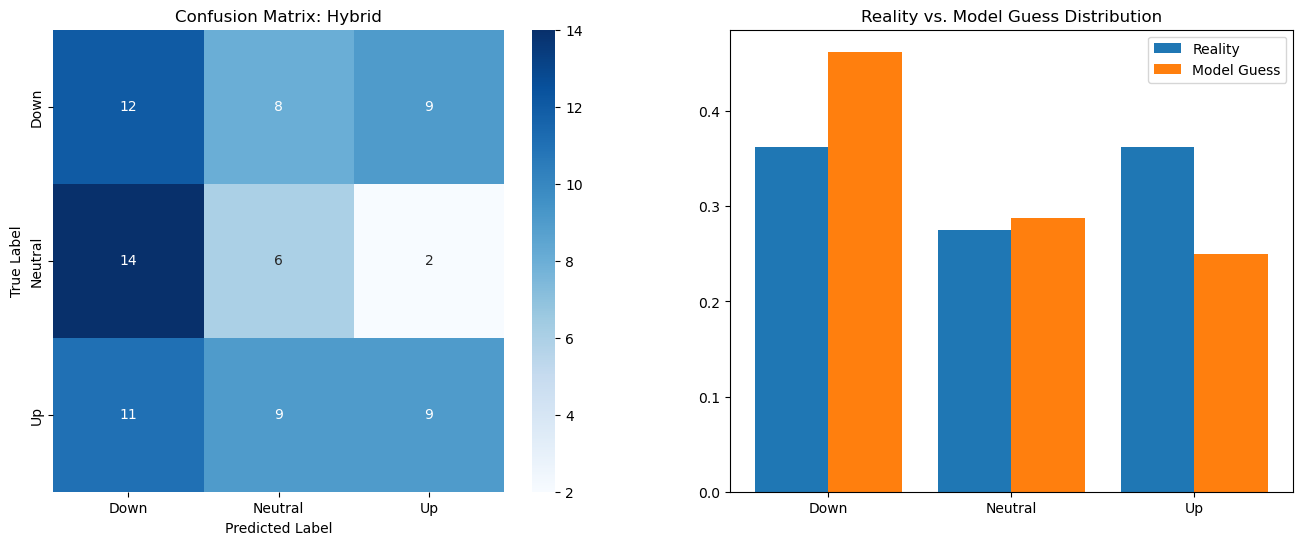

              precision    recall  f1-score   support

        Down       0.32      0.41      0.36        29
     Neutral       0.26      0.27      0.27        22
          Up       0.45      0.31      0.37        29

    accuracy                           0.34        80
   macro avg       0.35      0.33      0.33        80
weighted avg       0.35      0.34      0.34        80



In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def plot_performance_analysis(true_labels, predicted_labels, title):
    # 1. Calculate Confusion Matrix
    cm = confusion_matrix(true_labels, predicted_labels)

    # 2. Calculate Distributions
    unique_true, counts_true = np.unique(true_labels, return_counts=True)
    unique_pred, counts_pred = np.unique(predicted_labels, return_counts=True)

    dist_true = dict(zip(unique_true, counts_true / len(true_labels)))
    dist_pred = dict(zip(unique_pred, counts_pred / len(predicted_labels)))

    # --- Visualization ---
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap of Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0],
                xticklabels=['Down', 'Neutral', 'Up'],
                yticklabels=['Down', 'Neutral', 'Up'])
    ax[0].set_title(f'Confusion Matrix: {title}')
    ax[0].set_xlabel('Predicted Label')
    ax[0].set_ylabel('True Label')

    # Bar chart of Distributions
    labels = ['Down', 'Neutral', 'Up']
    true_vals = [dist_true.get(i, 0) for i in range(3)]
    pred_vals = [dist_pred.get(i, 0) for i in range(3)]

    x = np.arange(len(labels))
    ax[1].bar(x - 0.2, true_vals, 0.4, label='Reality')
    ax[1].bar(x + 0.2, pred_vals, 0.4, label='Model Guess')
    ax[1].set_xticks(x)
    ax[1].set_xticklabels(labels)
    ax[1].set_title('Reality vs. Model Guess Distribution')
    ax[1].legend()

    plt.show()

    print(classification_report(true_labels, predicted_labels,
                                target_names=['Down', 'Neutral', 'Up']))

# Run analysis for both models
print("ANALYZING NEURAL NETWORK ONLY:")
plot_performance_analysis(test_labels, nn_only_preds, "NN Only")

print("\nANALYZING HYBRID (NN + XGBOOST):")
plot_performance_analysis(test_labels, final_preds, "Hybrid")